In [16]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.layers import (
    Input, Conv1D, MaxPool1D, BatchNormalization,
    Dense, Flatten, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy

from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [6]:
import kagglehub

path = kagglehub.dataset_download("shayanfazeli/heartbeat")

train_df = pd.read_csv(os.path.join(path, 'mitbih_train.csv'), header=None)
test_df  = pd.read_csv(os.path.join(path, 'mitbih_test.csv'), header=None)

train_df[187] = train_df[187].astype(int)
test_df[187]  = test_df[187].astype(int)

Using Colab cache for faster access to the 'heartbeat' dataset.


In [7]:
SAMPLE_COUNTS = {
    0: 20000,
    1: 15000,
    2: 15000,
    3: 12000,
    4: 12000
}

dfs = []
for cls, n in SAMPLE_COUNTS.items():
    subset = train_df[train_df[187] == cls]
    if len(subset) >= n:
        dfs.append(subset.sample(n=n, random_state=42))
    else:
        dfs.append(resample(subset, replace=True, n_samples=n, random_state=42+cls))

train_df = pd.concat(dfs).sample(frac=1, random_state=99).reset_index(drop=True)

In [8]:
def augment(signal):
    sig = signal.copy()
    sig += np.random.normal(0, 0.02, len(sig))
    sig *= np.random.uniform(0.95, 1.05)
    return sig

X_train = train_df.iloc[:, :186].values
y_train = train_df[187].values

X_train = X_train / np.max(np.abs(X_train))

X_train = np.array([augment(x) for x in X_train])

X_test = test_df.iloc[:, :186].values
X_test = X_test / np.max(np.abs(X_test))

X_train = X_train.reshape(-1, 186, 1).astype(np.float32)
X_test  = X_test.reshape(-1, 186, 1).astype(np.float32)

y_train = to_categorical(y_train, 5)
y_test  = to_categorical(test_df[187], 5)

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=np.argmax(y_train, axis=1),
    random_state=42
)

In [10]:
def build_model():
    inp = Input(shape=(186, 1))

    x = Conv1D(32, 5, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = MaxPool1D(2)(x)

    x = Conv1D(64, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPool1D(2)(x)

    x = Conv1D(128, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPool1D(2)(x)

    x = Flatten()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)

    # NO SOFTMAX HERE
    out = Dense(5)(x)

    return Model(inp, out)

In [11]:
model = build_model()

loss_fn = CategoricalCrossentropy(
    from_logits=True,
    label_smoothing=0.1
)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

In [12]:
class_weights = {
    0: 1.0,
    1: 2.5,
    2: 4.0,
    3: 1.5,
    4: 1.2
}

In [13]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.7910 - loss: 1.5784 - val_accuracy: 0.8599 - val_loss: 0.6720 - learning_rate: 3.0000e-04
Epoch 2/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 56s 61ms/step - accuracy: 0.8826 - loss: 1.2917 - val_accuracy: 0.9286 - val_loss: 0.5698 - learning_rate: 3.0000e-04
Epoch 3/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 88s 67ms/step - accuracy: 0.9098 - loss: 1.1911 - val_accuracy: 0.9366 - val_loss: 0.5386 - learning_rate: 3.0000e-04
Epoch 4/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 56s 61ms/step - accuracy: 0.9250 - loss: 1.1300 - val_accuracy: 0.9454 - val_loss: 0.5171 - learning_rate: 3.0000e-04
Epoch 5/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 53s 58ms/step - accuracy: 0.9394 - loss: 1.0846 - val_accuracy: 0.9590 - val_loss: 0.4975 - learning_rate: 3.0000e-04
Epoch 6/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 53s 58ms/step - accuracy: 0.9471 - loss: 1.0534 - val_accuracy: 0.9631 - val_loss: 0.4853 - learning_rate: 3.0000e-04
Epoch 7/40
925/925 ━━━━━━━━━━━━━━━━━━━━ 53s 57ms/ste

172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
── Baseline (argmax) ───────────────────────────────────────────────
              precision    recall  f1-score   support

           N     0.9941    0.9735    0.9837     18118
           S     0.6471    0.8507    0.7350       556
           V     0.8745    0.9675    0.9187      1448
           F     0.6493    0.8457    0.7346       162
           Q     0.9875    0.9857    0.9866      1608

    accuracy                         0.9699     21892
   macro avg     0.8305    0.9246    0.8717     21892
weighted avg     0.9743    0.9699    0.9714     21892



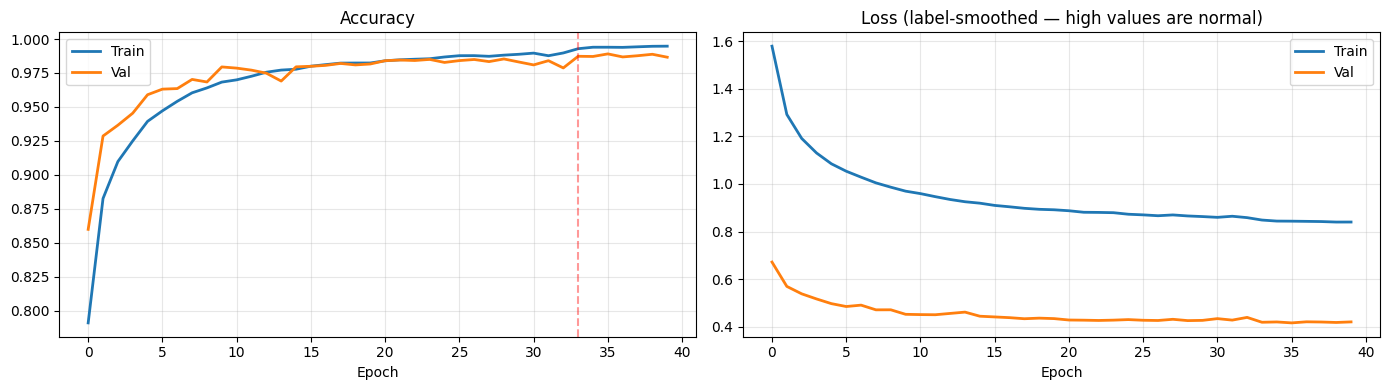

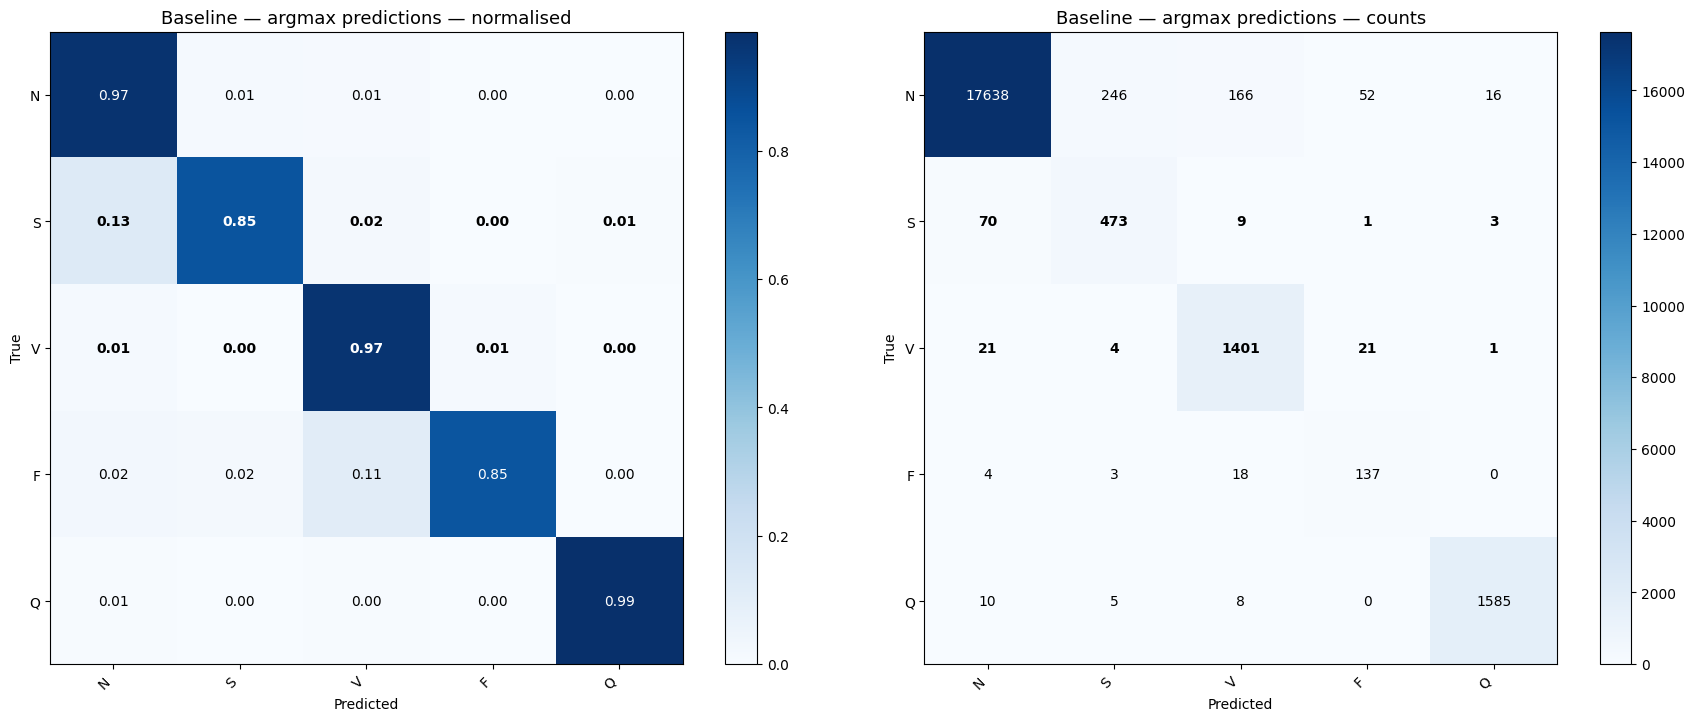


── Threshold sweep ─────────────────────────────────────────────────
  V_thr   S_thr    V_rec    S_rec    N_prec   macro_F1
   0.10    0.10    0.982    0.878     0.997      0.834
   0.10    0.15    0.982    0.858     0.996      0.842
   0.10    0.20    0.982    0.854     0.996      0.847
   0.10    0.25    0.982    0.853     0.996      0.854
   0.10    0.30    0.982    0.844     0.996      0.856
   0.10    0.35    0.982    0.838     0.995      0.858
   0.10    0.40    0.982    0.838     0.995      0.860
   0.10    0.45    0.982    0.835     0.995      0.861
   0.10    0.50    0.982    0.835     0.995      0.861
   0.15    0.10    0.978    0.894     0.996      0.837
   0.15    0.15    0.978    0.874     0.996      0.846
   0.15    0.20    0.978    0.867     0.995      0.850
   0.15    0.25    0.978    0.865     0.995      0.857
   0.15    0.30    0.978    0.854     0.995      0.860
   0.15    0.35    0.978    0.849     0.995      0.862
   0.15    0.40    0.978    0.849     0.995      0

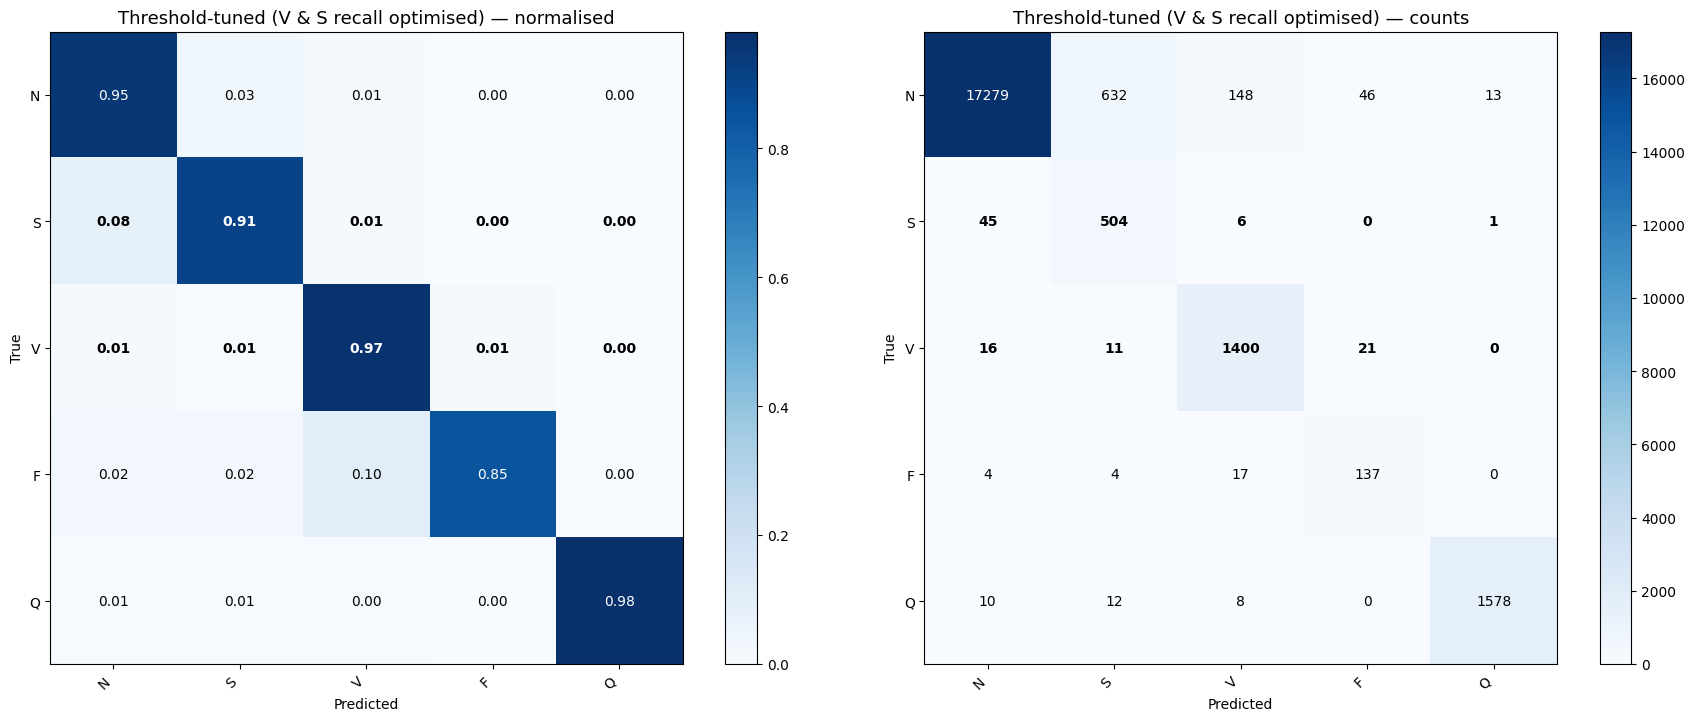

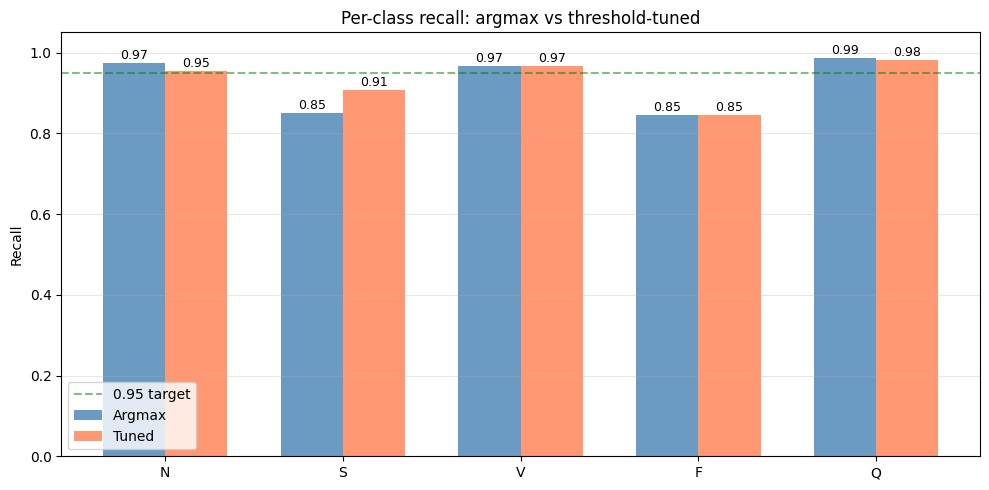


Thresholds saved → inference_thresholds.npy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step

Deploy model sanity check (max diff should be ~0): 0.0
SavedModel saved ecg_savedmodel/
Weights saved   → ecg_weights.h5
Saved artifact at '/tmp/tmp0lp2joow'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 186, 1), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135818753143056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135818753146704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135818753146128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135818753144400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135818753144208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135818753145360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135818753145552: TensorSpec(shape=(), dtype=tf.resou

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TFLite     → ecg_int8.tflite     (240.6 KB)

Running INT8 TFLite on test set (takes ~1 min)...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



── INT8 threshold sweep 
Best INT8 thresholds: (np.float64(0.25), np.float64(0.19))

── Quantization impact check ───────────────────────────────────────
Class    Keras (tuned)   INT8 TFLite     Drop
N               0.9537        0.9524  +0.0013
S               0.9065        0.8597  +0.0468 ◄ CHECK
V               0.9669        0.9807  -0.0138 ◄ CHECK
F               0.8457        0.7346  +0.1111
Q               0.9813        0.9695  +0.0118

Macro F1 — Keras: 0.8441  |  INT8: 0.8307


In [14]:
import itertools
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score
)
import matplotlib.pyplot as plt

CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
DANGER_IDX  = {1: 'S', 2: 'V'}

logits     = model.predict(X_test, batch_size=128)
y_proba    = tf.nn.softmax(logits).numpy()   # convert to probabilities
y_pred_raw = np.argmax(y_proba, axis=1)
y_true     = np.argmax(y_test,  axis=1)

print(" Baseline (argmax) ")
print(classification_report(y_true, y_pred_raw,
                             target_names=CLASS_NAMES, digits=4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3)

for ep, lr in enumerate(history.history['learning_rate']):
    if ep > 0 and lr < history.history['learning_rate'][ep-1]:
        ax1.axvline(ep, color='red', linestyle='--', alpha=0.4, label='LR drop')

ax2.plot(history.history['loss'],     label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val',   linewidth=2)
ax2.set_title('Loss (label-smoothed — high values are normal)')
ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, t in zip(
        axes,
        [cm_norm, cm],
        ['.2f', 'd'],
        [f'{title} — normalised', f'{title} — counts']
    ):
        im = ax.imshow(data, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(t, fontsize=13)
        plt.colorbar(im, ax=ax)
        ticks = np.arange(len(classes))
        ax.set_xticks(ticks); ax.set_xticklabels(classes, rotation=45, ha='right')
        ax.set_yticks(ticks); ax.set_yticklabels(classes)
        thresh = data.max() / 2.
        for i, j in itertools.product(range(data.shape[0]), range(data.shape[1])):
            weight = 'bold' if i in DANGER_IDX else 'normal'
            ax.text(j, i, format(data[i, j], fmt), ha='center', va='center',
                    color='white' if data[i, j] > thresh else 'black',
                    fontweight=weight)
        ax.set_ylabel('True'); ax.set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true, y_pred_raw, CLASS_NAMES,
                      title='Baseline — argmax predictions')

def predict_with_thresholds(proba, v_thresh, s_thresh):
    preds = []
    for p in proba:
        if p[2] >= v_thresh:
            preds.append(2)
        elif p[1] >= s_thresh:
            preds.append(1)
        else:
            preds.append(np.argmax(p))
    return np.array(preds)

print("\n Threshold sweep")
print(f"{'V_thr':>7} {'S_thr':>7} {'V_rec':>8} {'S_rec':>8} "
      f"{'N_prec':>9} {'macro_F1':>10}")

best = None
best_vs_score = 0.0

for v_t in np.arange(0.10, 0.55, 0.05):
    for s_t in np.arange(0.10, 0.55, 0.05):
        preds   = predict_with_thresholds(y_proba, v_t, s_t)
        recalls = recall_score(y_true, preds, average=None, zero_division=0)
        precs   = precision_score(y_true, preds, average=None, zero_division=0)
        macro   = f1_score(y_true, preds, average='macro', zero_division=0)
        vs      = (recalls[1] + recalls[2]) / 2

        print(f"{v_t:>7.2f} {s_t:>7.2f} {recalls[2]:>8.3f} "
              f"{recalls[1]:>8.3f} {precs[0]:>9.3f} {macro:>10.3f}")


        if vs > best_vs_score and precs[0] > 0.88:
            best_vs_score = vs
            best = dict(v_thresh=v_t, s_thresh=s_t,
                        V_recall=recalls[2], S_recall=recalls[1],
                        N_prec=precs[0],    macro_F1=macro)

print(f"\n Best thresholds")
print(f"  V threshold : {best['v_thresh']:.2f}  →  V recall : {best['V_recall']:.4f}")
print(f"  S threshold : {best['s_thresh']:.2f}  →  S recall : {best['S_recall']:.4f}")
print(f"  N precision : {best['N_prec']:.4f}")
print(f"  Macro F1    : {best['macro_F1']:.4f}")

y_pred_tuned = predict_with_thresholds(
    y_proba, best['v_thresh'], best['s_thresh']
)

print("\n Tuned Classification Report")
print(classification_report(y_true, y_pred_tuned,
                             target_names=CLASS_NAMES, digits=4))

plot_confusion_matrix(y_true, y_pred_tuned, CLASS_NAMES,
                      title='Threshold-tuned (V & S recall optimised)')

rec_raw   = recall_score(y_true, y_pred_raw,   average=None)
rec_tuned = recall_score(y_true, y_pred_tuned, average=None)

x = np.arange(5)
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, rec_raw,   w, label='Argmax',  color='steelblue', alpha=0.8)
ax.bar(x + w/2, rec_tuned, w, label='Tuned',   color='coral',     alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.05); ax.set_ylabel('Recall')
ax.set_title('Per-class recall: argmax vs threshold-tuned')
ax.axhline(0.95, linestyle='--', color='green', alpha=0.5, label='0.95 target')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for i in range(5):
    ax.text(i - w/2, rec_raw[i]   + 0.01, f'{rec_raw[i]:.2f}',   ha='center', fontsize=9)
    ax.text(i + w/2, rec_tuned[i] + 0.01, f'{rec_tuned[i]:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

np.save('inference_thresholds.npy', best)



from tensorflow.keras.layers import Softmax

inp_deploy  = Input(shape=(186, 1))
logits_out  = model(inp_deploy)
proba_out   = Softmax()(logits_out)
deploy_model = Model(inp_deploy, proba_out, name='ecg_deploy')
deploy_model.set_weights(model.get_weights())


sample      = X_test[:5]
logit_proba = tf.nn.softmax(model.predict(sample)).numpy()
deploy_proba = deploy_model.predict(sample)
print("\nDeploy model sanity check (max diff should be ~0):",
      np.max(np.abs(logit_proba - deploy_proba)))


deploy_model.save('ecg_savedmodel.keras')

print("SavedModel saved ecg_savedmodel/")



deploy_model.save_weights('ecg.weights.h5')
print("Weights saved   → ecg_weights.h5")

converter_f32 = tf.lite.TFLiteConverter.from_keras_model(deploy_model)
tflite_f32    = converter_f32.convert()
with open('ecg_float32.tflite', 'wb') as f:
    f.write(tflite_f32)
print(f"Float32 TFLite  → ecg_float32.tflite  ({len(tflite_f32)/1024:.1f} KB)")

def representative_dataset():
    for cls in range(5):
        idx = np.where(y_true == cls)[0][:80]
        for i in idx:
            yield [X_test[i:i+1].astype(np.float32)]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(deploy_model)
converter_int8.optimizations             = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset   = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type     = tf.float32
converter_int8.inference_output_type    = tf.float32

tflite_int8 = converter_int8.convert()
with open('ecg_int8.tflite', 'wb') as f:
    f.write(tflite_int8)
print(f"INT8 TFLite     → ecg_int8.tflite     ({len(tflite_int8)/1024:.1f} KB)")

def run_tflite(model_content, X):
    interp = tf.lite.Interpreter(model_content=model_content)
    interp.allocate_tensors()
    inp_idx = interp.get_input_details()[0]['index']
    out_idx = interp.get_output_details()[0]['index']
    results = []
    for i in range(len(X)):
        interp.set_tensor(inp_idx, X[i:i+1].astype(np.float32))
        interp.invoke()
        results.append(interp.get_tensor(out_idx)[0])
    return np.array(results)

print("\nRunning INT8 TFLite on test set (takes ~1 min)...")
proba_int8  = run_tflite(tflite_int8, X_test)

print("\n── INT8 threshold sweep ")

best_int8 = None
best_score = 0

for v_t in np.arange(0.15, 0.30, 0.05):
    for s_t in np.arange(0.05, 0.20, 0.02):
        preds = predict_with_thresholds(proba_int8, v_t, s_t)

        recalls = recall_score(y_true, preds, average=None)
        vs_score = (recalls[1] + recalls[2]) / 2
from sklearn.metrics import precision_score

precs = precision_score(y_true, preds, average=None, zero_division=0)


if vs_score > best_score and precs[0] > 0.93:
    best_score = vs_score
    best_int8 = (v_t, s_t)

print("Best INT8 thresholds:", best_int8)

pred_int8 = predict_with_thresholds(proba_int8,
                                    best_int8[0], best_int8[1]-0.03)

rec_int8    = recall_score(y_true, pred_int8, average=None)
macro_int8  = f1_score(y_true, pred_int8, average='macro')

print("\n Quantization impact check")
print(f"{'Class':<6} {'Keras (tuned)':>15} {'INT8 TFLite':>13} {'Drop':>8}")
for i, name in enumerate(CLASS_NAMES):
    drop   = rec_tuned[i] - rec_int8[i]
    flag   = " ◄ CHECK" if (i in DANGER_IDX and abs(drop) > 0.01) else ""
    print(f"{name:<6} {rec_tuned[i]:>15.4f} {rec_int8[i]:>13.4f} "
          f"{drop:>+8.4f}{flag}")
print(f"\nMacro F1 — Keras: {best['macro_F1']:.4f}  |  INT8: {macro_int8:.4f}")

val_samples, val_labels = [], []
for cls in range(5):
    idx = np.where(y_true == cls)[0][:5]
    val_samples.append(X_test[idx])
    val_labels.extend([cls]*5)

val_samples = np.concatenate(val_samples)
val_labels  = np.array(val_labels)

np.save('zedboard_val_samples.npy', val_samples)
np.save('zedboard_val_labels.npy',  val_labels)
np.save('inference_thresholds.npy', best)


In [15]:
import numpy as np
import tensorflow as tf
import json, struct

deploy_model = tf.keras.models.load_model('ecg_savedmodel.keras')
print("Model loaded ✓")

import pandas as pd, os, kagglehub
path    = kagglehub.dataset_download("shayanfazeli/heartbeat")
test_df = pd.read_csv(os.path.join(path, 'mitbih_test.csv'), header=None)
test_df[187] = test_df[187].astype(int)
X_test  = test_df.iloc[:, :186].values
X_test  = X_test / np.max(np.abs(X_test))
X_test  = X_test.reshape(-1, 186, 1).astype(np.float32)
print(f"X_test loaded ✓  shape: {X_test.shape}")

V_THRESH = 0.20
S_THRESH = 0.10

def array_to_c(name, arr):
    flat = arr.flatten().astype(np.float32)
    vals = ',\n  '.join(f'{v:.8f}f' for v in flat)
    return f'static const float {name}[{len(flat)}] = {{\n  {vals}\n}};'

lines = []
lines.append('#ifndef ECG_WEIGHTS_H\n#define ECG_WEIGHTS_H\n')
lines.append(f'#define V_THRESHOLD {V_THRESH}f')
lines.append(f'#define S_THRESHOLD {S_THRESH}f\n')

conv_idx = dense_idx = bn_idx = 0

for layer in deploy_model.layers:
    w     = layer.get_weights()
    if not w:
        continue
    ltype = layer.__class__.__name__

    if ltype == 'Conv1D':
        ks, in_ch, out_ch = w[0].shape
        n = f'conv{conv_idx}'
        lines.append(f'/* Conv1D {conv_idx}: kernel({ks},{in_ch},{out_ch}) */')
        lines.append(f'#define {n.upper()}_KS  {ks}')
        lines.append(f'#define {n.upper()}_IN  {in_ch}')
        lines.append(f'#define {n.upper()}_OUT {out_ch}')
        lines.append(array_to_c(f'{n}_kernel', w[0]))
        lines.append(array_to_c(f'{n}_bias',   w[1]))
        conv_idx += 1

    elif ltype == 'BatchNormalization':
        n = f'bn{bn_idx}'
        lines.append(f'/* BatchNorm {bn_idx}: size={len(w[0])} */')
        lines.append(f'#define {n.upper()}_SIZE {len(w[0])}')
        lines.append(array_to_c(f'{n}_gamma', w[0]))
        lines.append(array_to_c(f'{n}_beta',  w[1]))
        lines.append(array_to_c(f'{n}_mean',  w[2]))
        lines.append(array_to_c(f'{n}_var',   w[3]))
        bn_idx += 1

    elif ltype == 'Dense':
        in_f, out_f = w[0].shape
        n = f'dense{dense_idx}'
        lines.append(f'/* Dense {dense_idx}: ({in_f}→{out_f}) */')
        lines.append(f'#define {n.upper()}_IN  {in_f}')
        lines.append(f'#define {n.upper()}_OUT {out_f}')
        lines.append(array_to_c(f'{n}_kernel', w[0]))
        lines.append(array_to_c(f'{n}_bias',   w[1]))
        dense_idx += 1

lines.append('#endif /* ECG_WEIGHTS_H */')

with open('ecg_weights.h', 'w') as f:
    f.write('\n'.join(lines))

total_params = sum(p.size for l in deploy_model.layers for p in l.get_weights())
print(f"\n ecg_weights.h")
print(f"Total params : {total_params:,}")
print(f"Float32 size : {total_params * 4 / 1024:.1f} KB")

def representative_data_gen():
    for i in range(200):
        yield [X_test[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(deploy_model)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset   = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type     = tf.float32
converter.inference_output_type    = tf.float32

tflite_model = converter.convert()
with open('ecg_cnn_int8.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"\n ecg_cnn_int8.tflite ")
print(f"INT8 TFLite size : {len(tflite_model)/1024:.1f} KB  saved")


all_weights_int8 = []
scale_factors    = {}

print(f"\n INT8 binary weights ")
for layer in deploy_model.layers:
    weights = layer.get_weights()
    if not weights:
        continue
    for i, w in enumerate(weights):
        w_max = np.max(np.abs(w))
        scale = w_max / 127.0 if w_max > 1e-8 else 1.0
        w_int8 = np.clip(np.round(w / scale), -128, 127).astype(np.int8)
        all_weights_int8.append(w_int8.flatten())
        key = f"{layer.name}_{i}"
        scale_factors[key] = float(scale)
        print(f"  {key:35s} shape={str(w.shape):20s} scale={scale:.6f}")

flat_weights = np.concatenate(all_weights_int8)
flat_weights.tofile('ecg_cnn_weights.bin')
print(f"\nTotal INT8 weights : {len(flat_weights):,} bytes")
print(f"Binary size        : {len(flat_weights)/1024:.1f} KB  → ecg_cnn_weights.bin ✓")

with open('scale_factors.json', 'w') as f:
    json.dump(scale_factors, f, indent=2)
print("Scale factors saved → scale_factors.json ✓")


scale_lines = ['#ifndef ECG_SCALES_H\n#define ECG_SCALES_H\n']
for key, scale in scale_factors.items():
    cname = key.replace('/', '_').replace(':', '_')
    scale_lines.append(f'#define SCALE_{cname.upper()} {scale:.8f}f')
scale_lines.append('\n#endif /* ECG_SCALES_H */')

with open('ecg_scales.h', 'w') as f:
    f.write('\n'.join(scale_lines))
print("Scale factors as C header → ecg_scales.h ✓")

samples = np.load('zedboard_val_samples.npy')   # shape (25, 186, 1)
labels  = np.load('zedboard_val_labels.npy')
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']

with open('test_samples.h', 'w') as f:
    f.write('#ifndef TEST_SAMPLES_H\n#define TEST_SAMPLES_H\n\n')
    f.write(f'#define N_TEST_SAMPLES {len(samples)}\n\n')
    f.write('static const int test_labels[N_TEST_SAMPLES] = {')
    f.write(', '.join(str(int(l)) for l in labels))
    f.write('};\n\n')
    for i, s in enumerate(samples):
        vals = ', '.join(f'{v:.6f}f' for v in s.flatten())
        f.write(f'/* sample {i} — true class: {CLASS_NAMES[int(labels[i])]} */\n')
        f.write(f'static const float test_sample_{i}[186] = {{{vals}}};\n\n')
    f.write('#endif /* TEST_SAMPLES_H */\n')

print(f"\n test_samples.h ")
print(f"{len(samples)} samples written ✓")

print("""
── Files to download from Kaggle output ────────────────
  ecg_weights.h        ← float32 weights as C arrays (bare-metal)
  ecg_scales.h         ← INT8 scale factors as C defines (bare-metal)
  ecg_cnn_weights.bin  ← INT8 binary weights (alternative path)
  ecg_cnn_int8.tflite  ← INT8 TFLite model (if using TFLite runtime)
  scale_factors.json   ← scale factors (PC reference only)
  test_samples.h       ← 25 validation samples for on-board test
""")

Model loaded ✓
Using Colab cache for faster access to the 'heartbeat' dataset.
X_test loaded ✓  shape: (21892, 186, 1)

── ecg_weights.h ───────────────────────────────────
Total params : 222,725
Float32 size : 870.0 KB
Saved artifact at '/tmp/tmpo1ncv19n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 186, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135818739499472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135821272116944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135821272117136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135817760131792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135821272116560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135821272117520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135817760134288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13581776

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



── ecg_cnn_int8.tflite ─────────────────────────────
INT8 TFLite size : 240.6 KB  saved ✓

── INT8 binary weights ─────────────────────────────
  functional_0                        shape=(5, 1, 32)           scale=0.002366
  functional_1                        shape=(32,)                scale=0.000353
  functional_2                        shape=(32,)                scale=0.009688
  functional_3                        shape=(32,)                scale=0.001005
  functional_4                        shape=(32,)                scale=0.000847
  functional_5                        shape=(32,)                scale=0.000152
  functional_6                        shape=(3, 32, 64)          scale=0.003288
  functional_7                        shape=(64,)                scale=0.001779
  functional_8                        shape=(64,)                scale=0.009615
  functional_9                        shape=(64,)                scale=0.003758
  functional_10                       shape=(64,)      